In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

import yfinance as yf
import quantstats as qs
from pypfopt import EfficientFrontier, risk_models

In [2]:
tickers = ['MSFT', 'GOOGL', 'NVDA', 'JNJ', 'AMZN']
data = yf.download(tickers, start='2020-01-01', end='2026-01-01')['Close']
data

Ticker,AMZN,GOOGL,JNJ,MSFT,NVDA
Date,,,,,
2020-01-02,94.900497,67.832512,121.936974,151.829529,5.963802
2020-01-03,93.748497,67.477654,120.525192,149.938995,5.868347
2020-01-06,95.143997,69.276222,120.374863,150.326599,5.892958
2020-01-07,95.343002,69.142395,121.109947,148.955948,5.964301
2020-01-08,94.598503,69.634544,121.093262,151.328583,5.975488
...,...,...,...,...,...
2025-12-24,232.380005,313.681671,205.499420,485.856323,188.380234
2025-12-26,232.520004,313.102478,205.351059,485.547699,190.297897
2025-12-29,232.070007,313.152405,205.281830,484.940430,187.990707


In [3]:
# на сколько процентов изменилась цена за 20 дней назад по отношению к сегодняшнему дню
# используется только для целевых переменных, в строку записываются изменения за следующие 20 дней для проверки точности предсказаний на эти дни
returns_20d = data.pct_change(20).shift(-20)
returns_20d

Ticker,AMZN,GOOGL,JNJ,MSFT,NVDA
Date,,,,,
2020-01-02,0.058330,0.046834,0.019867,0.059831,-0.014505
2020-01-03,0.068924,0.088930,0.040824,0.099357,0.018046
2020-01-06,0.077141,0.034053,0.052047,0.132616,0.042478
2020-01-07,0.069753,0.036513,0.062146,0.141642,0.045138
2020-01-08,0.083648,0.050483,0.059120,0.147042,0.057700
...,...,...,...,...,...
2025-12-24,NaN,NaN,NaN,NaN,NaN
2025-12-26,NaN,NaN,NaN,NaN,NaN
2025-12-29,NaN,NaN,NaN,NaN,NaN


In [4]:
def sequences(prices_scaled, targets_df, seq_len=30, horizon=20):
    X, y = [], []
    n = len(prices_scaled)

    for i in range(seq_len, n - horizon + 1):
        X.append(prices_scaled[i - seq_len : i])
        y.append(targets_df.iloc[i - 1].values)
    return np.array(X), np.array(y)

In [5]:
train_window = 252 * 3 # скользящее окно, на котором учится нейросеть (756 торговых дней)
test_step = 20 # на сколько дней рассчитан создаваемый портфель, т.е через сколько дней модель переобучается
seq_len = 30 # входные данные X для прогноза следующих 20 дней
horizon = 20 # на какой срок вперёд нейросеть пытается предсказать доходность

weights_all = [] # сохраняет веса всех составленных портфелей
step_dates = [] # сохраняет даты перебалансировок портфелей

pred_20d = [] # прогнозируемая доходность портфеля (в долях) на следующие 20 дней
real_20d = [] # фактическая доходность портфеля (в долях) за следующие 20 дней
real_daily = [] # записывает ежедневную доходность акций каждого 20-дневного отрезка

In [6]:
for t in range(train_window, len(data) - test_step, test_step):
    date = data.index[t] # текущая дата
    step_dates.append(date.strftime('%Y-%m-%d')) # запись даты перебалансировки

    train_vals = data.iloc[t - train_window:t] # входные данные за прошлые 30 дней для обучения (признаки)
    train_targets = returns_20d.iloc[t - train_window:t] # фактические значения доходностей за след. 20 дней, т.е. целевые переменные для обучения

    scaler = StandardScaler()
    train_vals_sc = scaler.fit_transform(train_vals) # нормализованные признаки

    X_train, y_train = sequences(train_vals_sc, train_targets, seq_len=seq_len, horizon=horizon) # разбивает три торговых года (756 дня) на X и y для обучения

    # модель LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(tickers)), return_sequences=False), # кол-во нейронов
        Dropout(0.2), # случайно выключает 20% нейронов на каждом шаге обучения
        Dense(len(tickers), kernel_regularizer=l2(0.01)) # l2 регуляризация
    ])
    model.compile(optimizer='adam', loss='huber') # оптимизатор adam, метрика huber для оценки
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    last_seq = train_vals_sc[-seq_len:][np.newaxis, :, :] # батч предыдущих 30 дней для 5 акций (1, 30, 5)
    pred_20d_returns = model.predict(last_seq, verbose=0).flatten() # прогноз на 20 дней вперёд

    cov_matrix = risk_models.risk_matrix(train_vals, method='ledoit_wolf') # матрица ковариаций с методом сжатия ледоит волф
    pred_series = pd.Series(pred_20d_returns * 12, index=tickers) # переводит 20-дневную доходность в годовую для составления портфеля
    ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4)) # эффективная граница Марковица

    # масимизация коэффициента Шарпа, подбирает самый выгодный портфель доход / риск
    try:
        ef.max_sharpe(risk_free_rate=0.0)
    except Exception:
        ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))
        ef.min_volatility()

    weights_cleaned = ef.clean_weights() # очистка математического шума весов
    weights = np.array([weights_cleaned[ticker] for ticker in tickers])
    weights_all.append(weights)

    pred_20d.append(np.sum(pred_20d_returns * weights)) # сохраняет фактическую доходность портфеля

    test_vals = data.iloc[t - 1:t + test_step] # тестовый период
    real_daily_returns = test_vals.pct_change().dropna()

    port_daily_returns = (real_daily_returns * weights).sum(axis=1) # доходность портфеля на каждый день
    real_daily.append(port_daily_returns)

    real_sum_20d = (1 + port_daily_returns).prod() - 1 # суммарная доходность портфеля за 20 дней
    real_20d.append(real_sum_20d)

C:\Users\Sofia\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
portfolio_returns = pd.concat(real_daily)
portfolio_returns.name = 'LSTM_Portfolio'
portfolio_returns.index = pd.to_datetime(portfolio_returns.index).tz_localize(None)

In [8]:
sp500 = yf.download('SPY', start=portfolio_returns.index[0], end=portfolio_returns.index[-1])['Close'] # цены S&P 500
sp500_returns = sp500.pct_change().dropna() # процентная доходность
sp500_returns.name = 'S&P 500'
sp500_returns.index = pd.to_datetime(sp500_returns.index).tz_localize(None)

df_returns = pd.concat([portfolio_returns, sp500_returns], axis=1).dropna()
portfolio_ret = df_returns['LSTM_Portfolio']
benchmark_ret = df_returns['SPY']

In [9]:
qs.extend_pandas()

print(f'cagr: {qs.stats.cagr(portfolio_ret) * 100}%')
print(f'шарп: {qs.stats.sharpe(portfolio_ret)}')
print(f'сортино: {qs.stats.sortino(portfolio_ret)}')
print(f'макс. просадка: {qs.stats.max_drawdown(portfolio_ret) * 100}%')
print(f'доля прибыльных дней: {qs.stats.win_rate(portfolio_ret) * 100}%')

cagr: 51.377336745814326%
шарп: 1.9988510623110707
сортино: 3.214101723843165
макс. просадка: -18.163457662758663%
доля прибыльных дней: 54.87804878048781%


In [10]:
qs.reports.html(portfolio_ret, benchmark=benchmark_ret, output='portfolio.html', title='LSTM Portfolio')

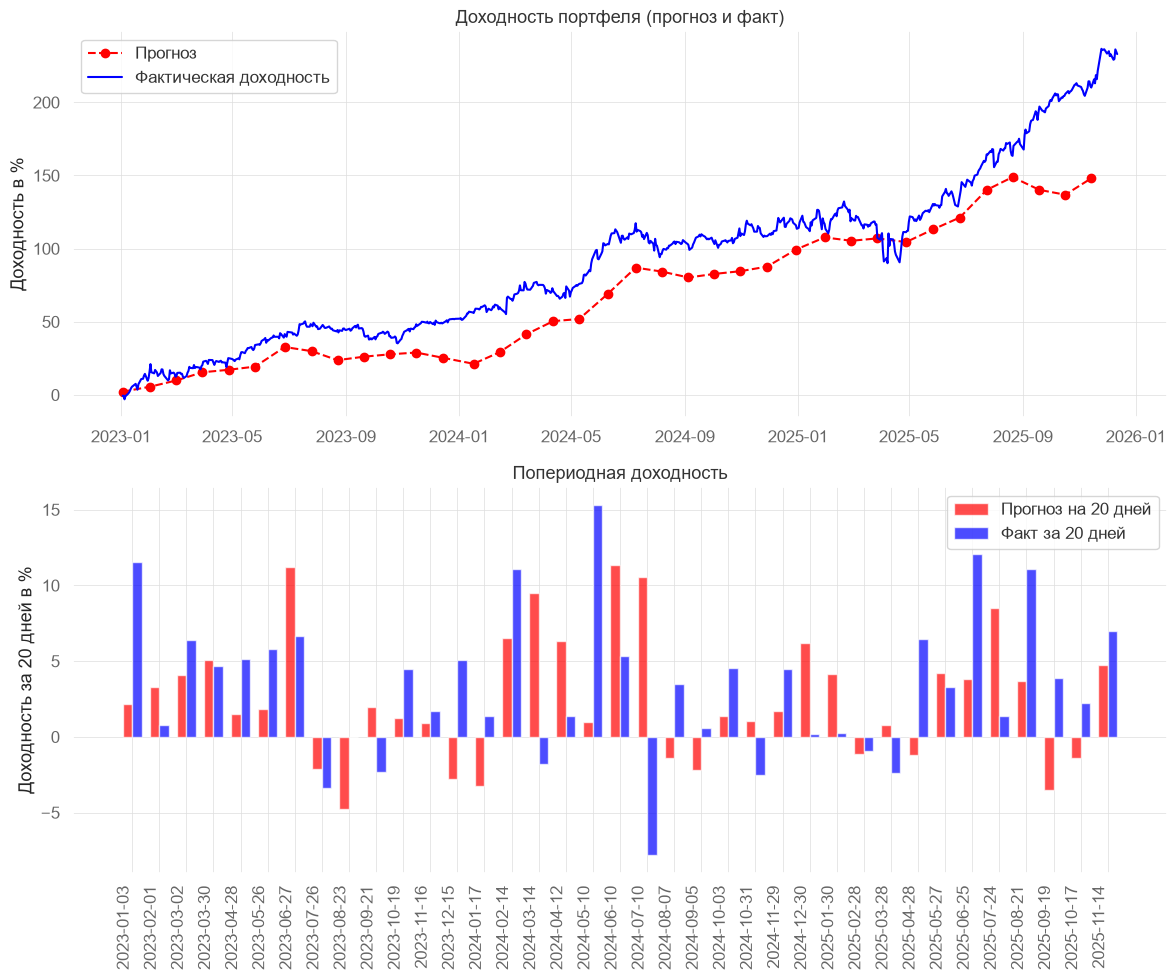

In [11]:
predicted = np.cumprod(1 + np.array(pred_20d)) - 1
actual_daily = (1 + portfolio_returns).cumprod() - 1
monthly_dates = pd.to_datetime(step_dates)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(monthly_dates, predicted * 100, label='Прогноз', color='red', linestyle='--', marker='o')
axes[0].plot(actual_daily.index, actual_daily * 100, label='Фактическая доходность', color='blue')
axes[0].set_title('Доходность портфеля (прогноз и факт)')
axes[0].set_ylabel('Доходность в %')
axes[0].grid(True)
axes[0].legend()

x = np.arange(len(step_dates))
width = 0.35

axes[1].bar(x - width/2, np.array(pred_20d) * 100, width, label='Прогноз на 20 дней', color='red', alpha=0.7)
axes[1].bar(x + width/2, np.array(real_20d) * 100, width, label='Факт за 20 дней', color='blue', alpha=0.7)
axes[1].set_title('Попериодная доходность')
axes[1].set_xticks(x)
axes[1].set_xticklabels(step_dates, rotation=90, ha='right')
axes[1].set_ylabel('Доходность за 20 дней в %')
axes[1].grid(True, axis='y')
axes[1].legend()

plt.tight_layout()
plt.show()